---
# **MACHINE LEARNING**
---

```text
1. Data Preprocessing
2. Train-Test SPLIT
3. Feature Engineering
4. Imbalance handling
5. Compare models
6. Select a model
7. Train Model
8. Evaluate Model
9. Improve Model
10. Deploy Model
```

<hr>

#### 🧰 INSTALLs


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: red;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [566]:
# install numpy and pandas if not already installed
#!pip install numpy pandas

# install xgboost if not already installed
#!pip install xgboost

# install shap if not already installed
#!pip install shap

# install imbalanced-lear
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


<hr>

#### 📂 IMPORTs


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: red;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [567]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

---
## **Data Preprocessing**
---

### **Load & View the data**

In this project, we will be working with Online Shoppers Intention UCI Machine Learning. The data can be found here:

https://www.kaggle.com/datasets/henrysue/online-shoppers-intention/data

Metadata



In [568]:
import pandas as pd

# load the clean dataset
df = pd.read_csv("../data/processed/online_shoppers_intention_01_standard.csv")
print("Dataset loaded successfully. Shape:", df.shape)
display(df.head())

Dataset loaded successfully. Shape: (12330, 18)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend,revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [569]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_duration  12330 non-null  float64
 6   bounce_rate            12330 non-null  float64
 7   exit_rate              12330 non-null  float64
 8   page_value             12330 non-null  float64
 9   special_day            12330 non-null  float64
 10  month                  12330 non-null  str    
 11  os                     12330 non-null  int64  
 12  browser                12330 non-null  int64  
 13  region                 12330 non-null  int64  
 14  traffic_type           12330 non-null  int64  
 15  visitor_type 

None

### **Check shape**

In [570]:
print("Shape:", df.shape[0], "rows and", df.shape[1], "columns\n")

Shape: 12330 rows and 18 columns



### **Check data types**

In [571]:
print("Data Types:")
df.dtypes

Data Types:


admin                      int64
admin_duration           float64
info                       int64
info_duration            float64
prod_related               int64
prod_related_duration    float64
bounce_rate              float64
exit_rate                float64
page_value               float64
special_day              float64
month                        str
os                         int64
browser                    int64
region                     int64
traffic_type               int64
visitor_type                 str
weekend                     bool
revenue                     bool
dtype: object

### **Check missing values**

There are multiple strategies to handle missing data
- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

In [572]:
print("Missing Values:")
print(df.isna().sum())
print(df.info())

Missing Values:
admin                    0
admin_duration           0
info                     0
info_duration            0
prod_related             0
prod_related_duration    0
bounce_rate              0
exit_rate                0
page_value               0
special_day              0
month                    0
os                       0
browser                  0
region                   0
traffic_type             0
visitor_type             0
weekend                  0
revenue                  0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_durat

In [573]:
# Loop print unique values of each column
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique values ({len(unique_vals)}): {unique_vals}\n")


Column: admin
Unique values (27): [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]

Column: admin_duration
Unique values (3335): [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]

Column: info
Unique values (17): [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]

Column: info_duration
Unique values (1258): [  0.   120.    16.   ... 547.75 368.25 211.25]

Column: prod_related
Unique values (311): [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 10

In [574]:
# loop through columns and print sum of nulls for each column
for col in df.columns:
    print(f"Null values in '{col}': [{df[col].isna().sum()}]")

Null values in 'admin': [0]
Null values in 'admin_duration': [0]
Null values in 'info': [0]
Null values in 'info_duration': [0]
Null values in 'prod_related': [0]
Null values in 'prod_related_duration': [0]
Null values in 'bounce_rate': [0]
Null values in 'exit_rate': [0]
Null values in 'page_value': [0]
Null values in 'special_day': [0]
Null values in 'month': [0]
Null values in 'os': [0]
Null values in 'browser': [0]
Null values in 'region': [0]
Null values in 'traffic_type': [0]
Null values in 'visitor_type': [0]
Null values in 'weekend': [0]
Null values in 'revenue': [0]


In [575]:
# compare the number of rows with the number of nulls in each column 
# to identify columns with a high percentage of missing values
print("Null values and percentage of nulls for each column:")
for col in df.columns:
    num_rows = df.shape[0]
    num_nulls = df[col].isna().sum()
    percent_nulls = (num_nulls / num_rows) * 100
    print(f"{col}: {num_nulls} nulls ({percent_nulls:.2f}%)")

Null values and percentage of nulls for each column:
admin: 0 nulls (0.00%)
admin_duration: 0 nulls (0.00%)
info: 0 nulls (0.00%)
info_duration: 0 nulls (0.00%)
prod_related: 0 nulls (0.00%)
prod_related_duration: 0 nulls (0.00%)
bounce_rate: 0 nulls (0.00%)
exit_rate: 0 nulls (0.00%)
page_value: 0 nulls (0.00%)
special_day: 0 nulls (0.00%)
month: 0 nulls (0.00%)
os: 0 nulls (0.00%)
browser: 0 nulls (0.00%)
region: 0 nulls (0.00%)
traffic_type: 0 nulls (0.00%)
visitor_type: 0 nulls (0.00%)
weekend: 0 nulls (0.00%)
revenue: 0 nulls (0.00%)


### **Check duplicates**

In [576]:
# print number of duplicated rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 125


### **Leakage Handling**
**DROP**
- identifier column (Id) and (Name), they are not useful features (high cardinality and not predictive)
- columns that are future information

Data leakage happens when:
- Information from the test set influences training
- Or when a feature contains **future information**
- Or when preprocessing is done **before splitting**

Very important:
- Remove post-event features
- Remove target proxies
- Remove ID-like features
- Check correlation with target
- Drop leakage features  
- Ensure no post-target info (variables) exists
- Fit transformations only on training set

Note:
- This step is more important than imbalance handling
- This step can be done either before or right after the step 2 - train/test split

In [577]:
# df = df.drop(["IDs", "Name",...], axis=1)

### **Deal with Nulls & Duplicates**

In [578]:
# remove nulls
# df = df.dropna()

# remove duplicates
# df = df.drop_duplicates()


### **Convert Data TYPE**

In [ ]:
# --- Convert Boolean to integer ---
# boolean columns
bool_cols = ["weekend", "revenue"]

# convert booleans to integers (True=1, False=0) for better modeling
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

---
### **CHECK PREPROCESSED DATA**

| Variable                    | Cat vs Num   | Identity | Original Python Type | Action            | Convert to | Definition |
|-----------------------------|-------------|----------|----------------------|-------------------|------------|------------|
| `admin`                     | Numerical   | Feature  | int                  | Keep              | -          | Number of administrative pages visited |
| `admin_duration`            | Numerical   | Feature  | float                | Keep              | -          | Time spent on administrative pages |
| `info`                      | Numerical   | Feature  | int                  | Keep              | -          | Number of informational pages visited |
| `info_duration`             | Numerical   | Feature  | float                | Keep              | -          | Time spent on informational pages |
| `prod_related`              | Numerical   | Feature  | int                  | Keep              | -          | Number of product-related pages visited |
| `prod_related_duration`     | Numerical   | Feature  | float                | Keep              | -          | Time spent on product-related pages |
| `bounce_rate`               | Numerical   | Feature  | float                | Keep              | -          | Website bounce rate |
| `exit_rate`                 | Numerical   | Feature  | float                | Keep              | -          | Website exit rate |
| `page_value`                | Numerical   | Feature  | float                | Keep              | -          | Average value of visited pages |
| `special_day`               | Numerical   | Feature  | float                | Keep              | -          | Closeness to special shopping day |
| `month`                     | Categorical | Feature  | str                  | One-Hot Encode    | int       | Month of visit |
| `os`                        | Categorical | Feature  | int                  | One-Hot Encode    | -          | Operating system of visitor |
| `browser`                   | Categorical | Feature  | int                  | One-Hot Encode    | -          | Browser used by visitor |
| `region`                    | Categorical | Feature  | int                  | One-Hot Encode    | -          | Geographic region of visitor |
| `traffic_type`              | Categorical | Feature  | int                  | One-Hot Encode    | -          | Traffic source type |
| `visitor_type`              | Categorical | Feature  | str                  | One-Hot Encode    | int       | Type of visitor (New/Returning) |
| `weekend`                   | Categorical | Feature  | bool                 | to binary | int       | Whether visit occurred on weekend |
| `revenue`                   | Categorical | Target   | bool                 | to binary | int       | Whether purchase was made |

In [580]:
# display cleaned dataframe
display(df.head())

,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend,revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [581]:
# display info cleaned dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_duration  12330 non-null  float64
 6   bounce_rate            12330 non-null  float64
 7   exit_rate              12330 non-null  float64
 8   page_value             12330 non-null  float64
 9   special_day            12330 non-null  float64
 10  month                  12330 non-null  str    
 11  os                     12330 non-null  int64  
 12  browser                12330 non-null  int64  
 13  region                 12330 non-null  int64  
 14  traffic_type           12330 non-null  int64  
 15  visitor_type 

In [582]:
# loop print unique values for each column
for col in df.columns:
        print(f"['{col}]': {df[col].unique()}")

['admin]': [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]
['admin_duration]': [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]
['info]': [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]
['info_duration]': [  0.   120.    16.   ... 547.75 368.25 211.25]
['prod_related]': [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 102 313 145  85  97 198 181 126 106 101 108 119
  70 122  91 276 100 291 114 172 217 141 133 156 136 180 135 195  99 362
 179 

---
## **Train-Test Split**

Now that we have split the data into **features** and **target** variables and imported the **train_test_split** function, split X and y into X_train, X_test, y_train, and y_test. 80% of the data should be in the training set and 20% in the test set.

### **Define target (y)**

In [583]:
# define target variable
y = df["revenue"]

### **Define features (X)**
```text
X = df.drop("revenue", axis=1)  # features without the target variable "revenue"
y = df["revenue"]               # target variable "revenue"
```

In [584]:
# define features
X = df.drop(["revenue"], axis=1)

### **SPLIT**
Use `random_state=42`, `stratify`

```text
X,                  # features without the target variable "revenue"
y,                  # target variable "revenue"
test_size=0.2,      # 20% test set, 80% train set
stratify=y,         # maintain class balance in splits
random_state=42     # for reproducibility, we can choose any integer as the random state
```

In [585]:

#split the data into training and testing sets (stratify by target variable to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#display the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9864, 17)
X_test shape: (2466, 17)
y_train shape: (9864,)
y_test shape: (2466,)


**Check split data**

In [586]:
print(f"Features=(X) and target=(y) separated. \nShapes:\nX =", X.shape, ", y =", y.shape)
print(100*"-")
print(f"Train/Test split completed. \nShapes: \nX_train = {X_train.shape}, y_train = {y_train.shape}, \nX_test = {X_test.shape}, y_test = {y_test.shape}")
print(100*"-")
print("Display X_train:")
display(X_train.head())

Features=(X) and target=(y) separated. 
Shapes:
X = (12330, 17) , y = (12330,)
----------------------------------------------------------------------------------------------------
Train/Test split completed. 
Shapes: 
X_train = (9864, 17), y_train = (9864,), 
X_test = (2466, 17), y_test = (2466,)
----------------------------------------------------------------------------------------------------
Display X_train:


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend
4263,8,732.25,0,0.0,34,1345.755952,0.005128,0.013342,12.274195,0.8,May,3,3,3,2,Returning_Visitor,0
5905,0,0.00,0,0.0,4,157.200000,0.040000,0.100000,0.000000,0.0,Oct,1,8,3,1,Returning_Visitor,1
9434,0,0.00,0,0.0,4,42.000000,0.000000,0.050000,0.000000,0.0,Dec,2,10,1,2,Returning_Visitor,0
3505,2,338.00,0,0.0,17,1205.566667,0.012500,0.037500,19.236250,0.8,May,3,2,2,2,Returning_Visitor,0
2067,0,0.00,0,0.0,32,827.646212,0.000000,0.000587,54.676348,0.0,Mar,2,2,7,2,Returning_Visitor,0


---
## **Feautres Engineering**

Steps to Features Engineering:

1. Identify Categorical vs Numerical Features

2. Encode Categorical Features & Scale Numerical Features
- Categorical Features:
    - Hot-one encoding for seperate categories
    - Labeling for ordinal variables
- Numerical Features:
    - Scaling because models can be sensitive to big numbers

3. Convert Target to numeric python type int (False=0; True=1) //Can also be done in the data prep
4. Convert all Features to numeric python type int or float //Can also be done in the data prep
5. Save `X_train.csv`,`X_test.csv` and `y_train.csv`,`y_test.csv`

### **1. Identify Categorical vs Numerical Features**

In [ ]:
# define categorical features
cat_cols = ["month", "os", "browser", "region", "traffic_type", "visitor_type"]
        
# define numerical features
num_cols = [col for col in X.columns if col not in cat_cols]

### **2. Encoding Cat & Scaling Num Features**

**All Models require Encoding Categorical Features** 
- OneHotEncoder (nominal)
- OrdinalEncoder (ordinal)
- Handle unknown categories when Encoding
- Avoid label encoding for nominal variables

**Scaling can be conditional per model:**
- **Models that require Scaling:** 
    - Linear models (Logistic Regression, Ridge, Lasso, ElasticNet)
    - Support Vector Machines (SVM)
    - K-Nearest Neighbors (KNN)
    - Neural Networks
    - K-Means / distance-based algorithms

- **Models that DON'T require Scaling:** 
    - Tree-based models (Decision Trees, Random Forest, XGBoost, LightGBM, CatBoost)



In [588]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OneHotEncoder

# ---- One-Hot Encode ----
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# categorical features in X_train
X_train_cat = pd.DataFrame(
    ohe.fit_transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)
# categorical features in X_test
X_test_cat = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

# ---- Scale Numerical ----
scaler = StandardScaler() 
# StandardScaler scales numerical features to have mean=0 and std=1

# numerical features in X_train
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

# numerical features in X_test
X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# ---- Replace original X_train and X_test ----
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

# display the shapes of the resulting sets
print("X_train shape after encoding and scaling:", X_train.shape)
display(X_train.head())
print("X_test shape after encoding and scaling:", X_test.shape)
display(X_test.head())

print("y_train shape:", y_train.shape)
display(y_train.head())
print("y_test shape:", y_test.shape)
display(y_test.head())

# ---- Save preprocessed data to CSV files ----
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


X_train shape after encoding and scaling: (9864, 74)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,weekend,month_Aug,month_Dec,month_Feb,month_Jul,month_June,month_Mar,month_May,month_Nov,month_Oct,month_Sep,os_1,os_2,os_3,os_4,os_5,os_6,os_7,os_8,browser_1,browser_2,browser_3,browser_4,browser_5,browser_6,browser_7,browser_8,browser_9,browser_10,browser_11,browser_12,browser_13,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,traffic_type_1,traffic_type_2,traffic_type_3,traffic_type_4,traffic_type_5,traffic_type_6,traffic_type_7,traffic_type_8,traffic_type_9,traffic_type_10,traffic_type_11,traffic_type_12,traffic_type_13,traffic_type_14,traffic_type_15,traffic_type_16,traffic_type_17,traffic_type_18,traffic_type_19,traffic_type_20,visitor_type_New_Visitor,visitor_type_Other,visitor_type_Returning_Visitor
4263,1.712088,3.624745,-0.395782,-0.244589,0.058405,0.083393,-0.353793,-0.612923,0.341014,3.663440,-0.549238,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5905,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.539163,0.360698,1.159262,-0.320268,-0.311499,1.820703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9434,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.599504,-0.458865,0.136746,-0.320268,-0.311499,-0.549238,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3505,-0.095698,1.429605,-0.395782,-0.244589,-0.331385,0.009963,-0.202751,-0.118883,0.716100,3.663440,-0.549238,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2067,-0.698294,-0.452341,-0.395782,-0.244589,0.012548,-0.187989,-0.458865,-0.873776,2.625461,-0.311499,-0.549238,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


X_test shape after encoding and scaling: (2466, 74)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,weekend,month_Aug,month_Dec,month_Feb,month_Jul,month_June,month_Mar,month_May,month_Nov,month_Oct,month_Sep,os_1,os_2,os_3,os_4,os_5,os_6,os_7,os_8,browser_1,browser_2,browser_3,browser_4,browser_5,browser_6,browser_7,browser_8,browser_9,browser_10,browser_11,browser_12,browser_13,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,traffic_type_1,traffic_type_2,traffic_type_3,traffic_type_4,traffic_type_5,traffic_type_6,traffic_type_7,traffic_type_8,traffic_type_9,traffic_type_10,traffic_type_11,traffic_type_12,traffic_type_13,traffic_type_14,traffic_type_15,traffic_type_16,traffic_type_17,traffic_type_18,traffic_type_19,traffic_type_20,visitor_type_New_Visitor,visitor_type_Other,visitor_type_Returning_Visitor
4722,-0.396996,-0.430070,-0.395782,-0.244589,-0.423100,-0.537085,0.045482,0.372711,-0.320268,2.669705,-0.549238,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6835,-0.396996,-0.323166,-0.395782,-0.244589,-0.193812,-0.469603,-0.458865,-0.204093,-0.320268,-0.311499,-0.549238,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5524,-0.698294,-0.452341,-0.395782,-0.244589,-0.583602,-0.571743,0.126537,-0.301476,4.331161,-0.311499,-0.549238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
663,-0.698294,-0.452341,-0.395782,-0.244589,-0.675317,-0.612599,-0.458865,1.159262,-0.320268,-0.311499,-0.549238,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
136,-0.698294,-0.452341,-0.395782,-0.244589,-0.514815,-0.462445,-0.345036,0.061004,-0.320268,-0.311499,-0.549238,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


y_train shape: (9864,)


4263    0
5905    0
9434    0
3505    1
2067    1
Name: revenue, dtype: int32

y_test shape: (2466,)


4722    0
6835    0
5524    1
663     0
136     0
Name: revenue, dtype: int32

In [605]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 74 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   admin                           9864 non-null   int64  
 1   admin_duration                  9864 non-null   float64
 2   info                            9864 non-null   int64  
 3   info_duration                   9864 non-null   float64
 4   prod_related                    9864 non-null   int64  
 5   prod_related_duration           9864 non-null   float64
 6   bounce_rate                     9864 non-null   float64
 7   exit_rate                       9864 non-null   float64
 8   page_value                      9864 non-null   float64
 9   special_day                     9864 non-null   float64
 10  weekend                         9864 non-null   bool   
 11  month_Aug                       9864 non-null   float64
 12  month_Dec                       9864 non-null

---
## **Imbalance handling**

**Target distribution**, Class balance percentages:
- Class True  = 1 :  /  ≈ 15%
- Class False = 0 :  /  ≈ 85%

imbalanced = 15/85%

**Important decision!** Which to Use:
- SMOTE?
- Random under-sampling?
- class_weight?
- threshold tuning?

⚠️ VERY IMPORTANT:
Apply SMOTE only on training set inside cross-validation fold. Otherwise → leakage.

#### Option A — Use Class Weights (Most Standard & Clean) 

In [590]:
# class_weight='balanced'

In [591]:
# class_weight = ?

#### Option B — Resampling (Use Carefully)

#### Option C — Threshold Tuning (Often Overlooked) 

---
# **Select Model (XGBoost)**

XGBoost has a built-in way to handle class imbalance using the scale_pos_weight parameter.

**Why use it:**
- State-of-the-art for structured/tabular data
- Handles imbalance well
- Often best performer

**Tune:**
- `learning_rate`
- `n_estimators`
- `max_depth`
- `scale_pos_weight` (important for imbalance)

---

### **Load Train/Test CSVs**

In [592]:
import pandas as pd
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")   
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

### **SANITY CHECK**

In [593]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# sanity check - check class distribution in target variable
print("Train class distribution:")
print(y_train.value_counts()) # count of each class
print(y_train.value_counts(normalize=True).round(2)) # percentage of each class
print(100*"-")
print("Test class distribution:")
print(y_test.value_counts())  # count of each class
print(y_test.value_counts(normalize=True).round(2)) # percentage of each class
print(100*"-")


Train shape: (9864, 74) (9864, 1)
Test shape: (2466, 74) (2466, 1)
Train class distribution:
revenue
False      8338
True       1526
Name: count, dtype: int64
revenue
False      0.85
True       0.15
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Test class distribution:
revenue
False      2084
True        382
Name: count, dtype: int64
revenue
False      0.85
True       0.15
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------


### **Define Model**

In [594]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Flatten target
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# define XGBoost model
model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

### **Train Model**

**Purpose** →  Train the selected algorithm on the training data to learn patterns and relationships between features and the target variable. 

In [595]:
# fit the model to the training data
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### **Evaluate Model**

Evaluate the XGBOOST model on the test data

**Metrics:** 
- `Accuracy`, // this metric is not reliable
- `Classification Report`, 
- `PR/ROC - AUC`, 
- `Confusion Matrix`

**🎯 Metrics to Prioritize:**

1️⃣ Test ROC AUC (Most Important)
- Measures ranking quality
- Threshold independent
- Best overall indicator of model quality

2️⃣ Test Accuracy
- Easy interpretability
- Good when classes are balanced (yours are balanced)

3️⃣ Overfitting Gap (Train vs Test)
- Small gap = better generalization
- Large gap = overfitting
- PR AUC and F1 were supportive but secondary.


In [596]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    average_precision_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix
)
import xgboost

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)

# Classification Report
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred))

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_proba)
print("XGBoost PR AUC:", pr_auc)

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("XGBoost ROC AUC:", roc_auc)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("XGBoost Confusion Matrix:\n", conf_matrix)

# MCC
mcc = matthews_corrcoef(y_test, y_pred)
print("MCC:", mcc)

# check overfitting or underfitting by comparing train and test performance
# comparing Train vs Test performance
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print("Test ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print(100*"-")

XGBoost Accuracy: 0.902676399026764
XGBoost Classification Report:

              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.73      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.90      0.90      0.90      2466

XGBoost PR AUC: 0.7469250488215831
XGBoost ROC AUC: 0.9301622433700796
XGBoost Confusion Matrix:
 [[1999   85]
 [ 155  227]]
MCC: 0.6023679218909241
Test ROC AUC: 0.9301622433700796
Test PR AUC: 0.7469250488215831
----------------------------------------------------------------------------------------------------


### **Precision-Recall Curve PLOT**

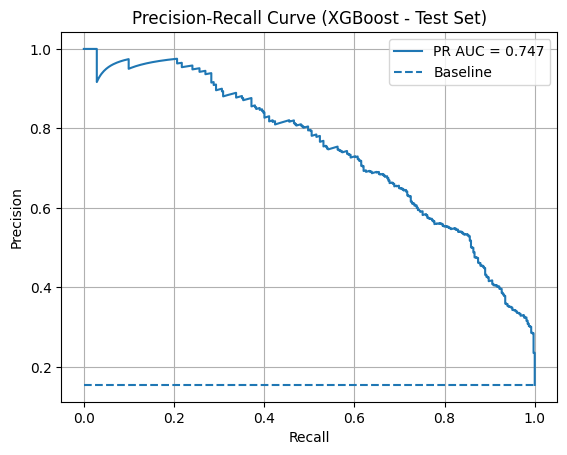

In [597]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# PR AUC
pr_auc = average_precision_score(y_test, y_proba)

# Baseline
baseline = y_test.mean()

# Reset to matplotlib defaults
plt.rcdefaults()

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.hlines(baseline, 0, 1, linestyles="dashed", label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost - Test Set)")
plt.legend()
plt.grid()
plt.show()

---
### **Check whether Model is over/under - fitting**

- **Good generalization**  Small difference → model generalizes well.

- **OVERFITTING:** 
    - Large gap → model memorized training data. 
    - Rule of Thumb → If(Train − Test > 5–7%) probably overfitting.
- **UNDERFITTING:** Both low → model too simple.

#### Compare Train vs Test AUC (more reliable than accuracy)

In [598]:
from sklearn.metrics import roc_auc_score

# Predicted probabilities
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

# AUC scores
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Difference: {train_auc - test_auc:.4f}")

Train AUC: 0.9472
Test AUC:  0.9302
Difference: 0.0170


---
### **CROSS VALIDATION**

- If CV score ≈ test score → good.
- If CV score much lower than train → overfitting.

In [599]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score
import numpy as np

# Stratified K-Fold for classification
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation with train + validation scores
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

# Extract AUC scores
train_auc = cv_results["train_score"]
val_auc = cv_results["test_score"]

print("Train AUC per fold:", np.round(train_auc, 4))
print("Validation AUC per fold:", np.round(val_auc, 4))

print("\nMean Train AUC:", round(train_auc.mean(), 4))
print("Mean Validation AUC:", round(val_auc.mean(), 4))
print("Validation AUC Std:", round(val_auc.std(), 4))

Train AUC per fold: [0.95   0.9501 0.9502 0.9475 0.9495]
Validation AUC per fold: [0.9288 0.9319 0.9275 0.9383 0.935 ]

Mean Train AUC: 0.9495
Mean Validation AUC: 0.9323
Validation AUC Std: 0.004


---
## **IMPROVE MODEL**
**Purpose** → Optimize model performance and improve generalization by refining model settings and feature selection.

#### **Adjust Decision Threshold**

- **Instead of 0.5 → ?**
- **This should improve recall.**

#### **Feature Importance Analysis**
**For RF / XGBoost: Use  `.feature_importances_`**

#### **Feature Selection**

#### **Reducing overfitting or underfitting**

### Tune parameters using RandomizedSearchCV
- `learning_rate`
- `n_estimators`
- `max_depth`
- `scale_pos_weight` (important for imbalance)


In [600]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# define XGBoost model
model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

#### Calculate scale_pos_weight (if imbalanced)

In [601]:
# Calculate class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 5.463958060288335


#### Grid Search for Tuning

In [602]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Parameter grid
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "scale_pos_weight": [1, scale_pos_weight]
}

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 1}
Best CV AUC: 0.9328598158392228


#### FIT & EVALUATE AGAIN AFTER TUNING PARAMETRES

In [603]:
# fit the model to the training data
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [604]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    average_precision_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix
)
import xgboost

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)

# Classification Report
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred))

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_proba)
print("XGBoost PR AUC:", pr_auc)

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("XGBoost ROC AUC:", roc_auc)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("XGBoost Confusion Matrix:\n", conf_matrix)

# MCC
mcc = matthews_corrcoef(y_test, y_pred)
print("MCC:", mcc)
print(100*"-")
# check overfitting or underfitting by comparing train and test performance
# comparing Train vs Test performance
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print("Test ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print(100*"-")

XGBoost Accuracy: 0.902676399026764
XGBoost Classification Report:

              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.73      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.90      0.90      0.90      2466

XGBoost PR AUC: 0.7469250488215831
XGBoost ROC AUC: 0.9301622433700796
XGBoost Confusion Matrix:
 [[1999   85]
 [ 155  227]]
MCC: 0.6023679218909241
----------------------------------------------------------------------------------------------------
Test ROC AUC: 0.9301622433700796
Test PR AUC: 0.7469250488215831
----------------------------------------------------------------------------------------------------


---
## **DEPLOY MODEL**
Using `Streamlit` for an interface for Real Time Prediction

---
## **NOTES**

👉 Best model by ROC-AUC: XGBoost (0.9275)
- It has the highest ability to rank positive cases above negative cases.

⚠️ Is ROC-AUC enough for imbalanced data? Short answer: No, it is not enough.
- ROC-AUC can be misleading for imbalanced datasets because:
    - It evaluates performance across all classification thresholds.
    - It gives equal importance to True Positive Rate (TPR) and False Positive Rate (FPR).
    - When negatives heavily outnumber positives, the FPR can look artificially small, inflating ROC-AUC.
    - In highly imbalanced data, a model can achieve high ROC-AUC but still perform poorly at identifying the minority class.

🔎 For imbalanced datasets, prioritize:

1️⃣ Precision-Recall AUC (PR-AUC) ⭐ (Very Important)
- More informative when the positive class is rare.
- Focuses only on the positive class performance.

2️⃣ F1-score
- Harmonic mean of precision and recall.
- Good when you need balance between false positives and false negatives.

3️⃣ Recall (Sensitivity)
- Important if missing positives is costly (e.g., fraud, disease).

4️⃣ Confusion Matrix
- Shows actual classification behavior at your chosen threshold.


📊 Recommended Evaluation Metrics (Very Important)

Because the dataset is IMBALANCED:

✅ PR/ROC-AUC
✅ Precision / Recall
✅ F1-score
✅ F2-score
❌ Avoid relying only on accuracy